# Task 2: Exploratory Data Analysis (EDA)
**Ethiopia Financial Inclusion Forecasting System**

This notebook explores the unified dataset for financial inclusion in Ethiopia, analyzing historical trajectories, mobile money expansion, gender gaps, and key infrastructure enablers to identify drivers of financial inclusion and understand the dynamics of the 2021-2024 slowdown.

In [1]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Load Data & Overview
We load the processed dataset `enriched_unified_data.csv` which contains the original data combined with our Task 1 additions.

In [2]:
df = pd.read_csv('../data/processed/enriched_unified_data.csv')
print(f'Total records in dataset: {len(df)}')

# Filter records by type
obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
targets = df[df['record_type'] == 'target'].copy()

print(f'Observations: {len(obs)}')
print(f'Events: {len(events)}')
print(f'Targets: {len(targets)}')

# Print summary by record type and pillar
print('\n--- Distribution by Record Type and Pillar ---')
print(df.groupby(['record_type', 'pillar']).size().unstack(fill_value=0))

Total records in dataset: 79
Observations: 39
Events: 15
Targets: 6

--- Distribution by Record Type and Pillar ---
pillar       ACCESS  AFFORDABILITY  GENDER  USAGE  access  enabler  \
record_type                                                          
impact_link       4              3       1      6       3        0   
observation      14              1       4     11       0        3   
target            2              0       1      0       2        0   

pillar       infrastructure  usage  
record_type                         
impact_link               0      2  
observation               6      0  
target                    0      1  


## 2. Temporal Coverage & Confidence Levels Analysis
We analyze which years have data for which indicators, and evaluate the overall data quality using confidence ratings.

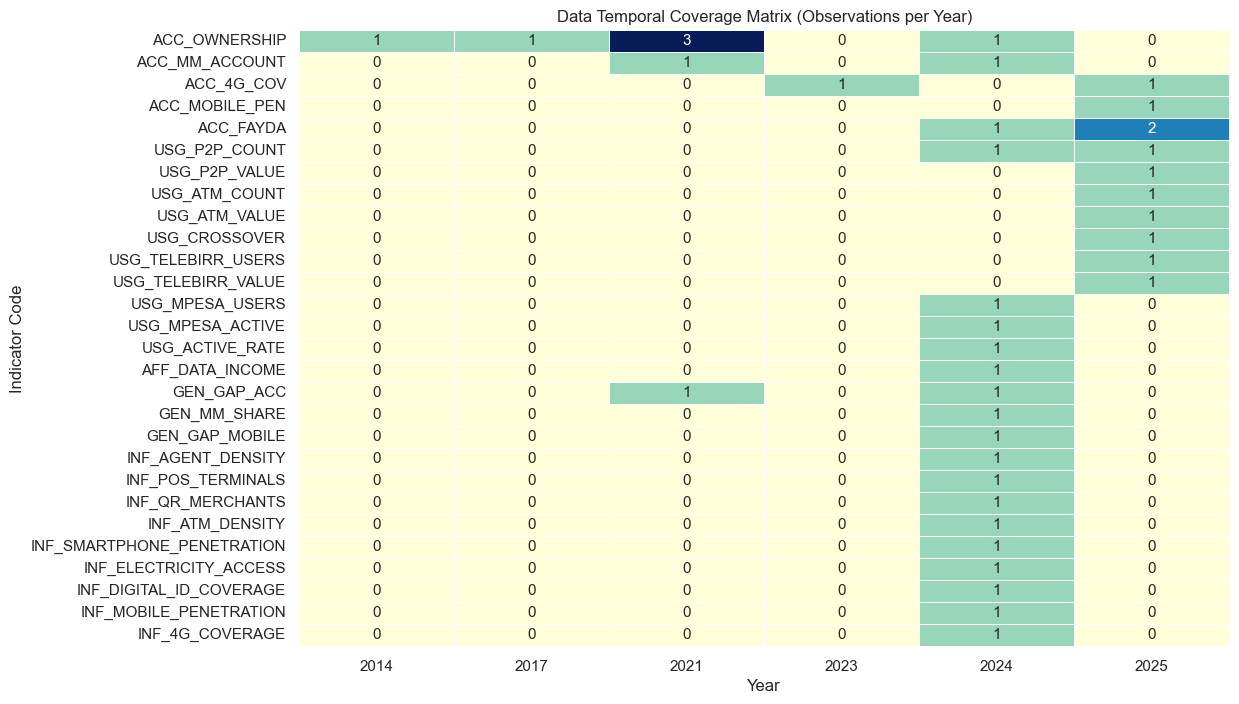

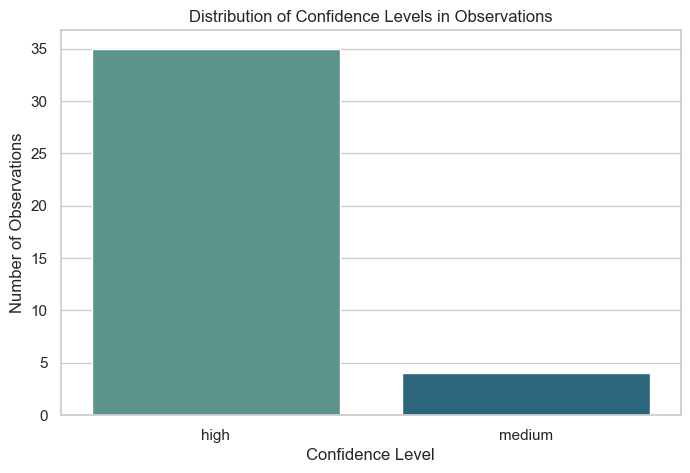

In [3]:
# Preprocess observation dates
obs['observation_date'] = pd.to_datetime(obs['observation_date'])
obs['year'] = obs['observation_date'].dt.year

# coverage heatmap
indicators = obs['indicator_code'].unique()
years = sorted(obs['year'].unique())
coverage_matrix = pd.DataFrame(0, index=indicators, columns=years)
for _, row in obs.iterrows():
    coverage_matrix.loc[row['indicator_code'], row['year']] += 1

plt.figure(figsize=(12, 8))
sns.heatmap(coverage_matrix, annot=True, cmap='YlGnBu', cbar=False, linewidths=.5)
plt.title('Data Temporal Coverage Matrix (Observations per Year)')
plt.xlabel('Year')
plt.ylabel('Indicator Code')
plt.show()

# Confidence rating distribution
plt.figure(figsize=(8, 5))
conf_counts = obs['confidence'].value_counts()
sns.barplot(x=conf_counts.index, y=conf_counts.values, palette='crest')
plt.title('Distribution of Confidence Levels in Observations')
plt.xlabel('Confidence Level')
plt.ylabel('Number of Observations')
plt.show()

## 3. Account Ownership (Access) Analysis
We plot the Global Findex account ownership results (including a baseline value of 14% in 2011 from global reports), calculate growth rates, and investigate the gender gap.

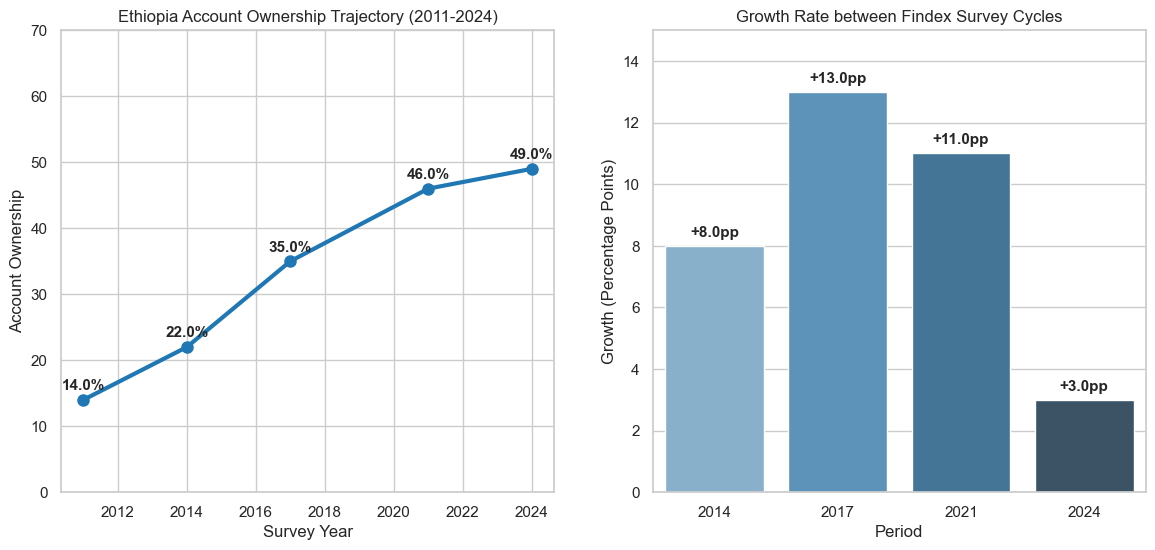

In [4]:
findex_years = [2011, 2014, 2017, 2021, 2024]
findex_values = [14.0, 22.0, 35.0, 46.0, 49.0]
growth_dates = findex_years[1:]
growth_rates = [findex_values[i] - findex_values[i-1] for i in range(1, len(findex_values))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(findex_years, findex_values, marker='o', linewidth=3, color='#1f77b4', markersize=8)
for y, val in zip(findex_years, findex_values):
    ax1.text(y, val + 1.5, f'{val}%', ha='center', fontweight='bold')
ax1.set_ylim(0, 70)
ax1.set_title('Ethiopia Account Ownership Trajectory (2011-2024)')
ax1.set_xlabel('Survey Year')
ax1.set_ylabel('Account Ownership')

sns.barplot(x=growth_dates, y=growth_rates, ax=ax2, palette='Blues_d')
for idx, val in enumerate(growth_rates):
    ax2.text(idx, val + 0.3, f'+{val}pp', ha='center', fontweight='bold')
ax2.set_title('Growth Rate between Findex Survey Cycles')
ax2.set_xlabel('Period')
ax2.set_ylabel('Growth (Percentage Points)')
ax2.set_ylim(0, 15)
plt.show()

### Gender Gap Evolution
Here we visualize how account ownership differ between genders in 2021 and 2024.

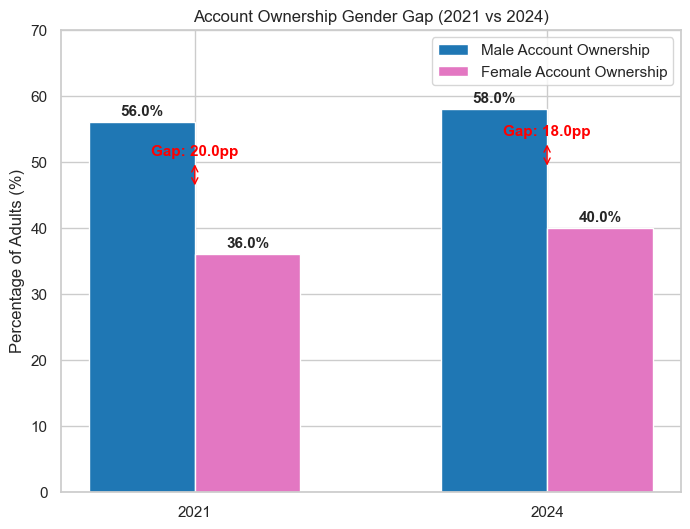

In [5]:
gender_years = [2021, 2024]
male_vals = [56.0, 58.0] # 2021 is actual Findex, 2024 is projected from 18pp gap
female_vals = [36.0, 40.0]
gap_vals = [20.0, 18.0]

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(gender_years))
width = 0.3
ax.bar(x - width/2, male_vals, width, label='Male Account Ownership', color='#1f77b4')
ax.bar(x + width/2, female_vals, width, label='Female Account Ownership', color='#e377c2')
for i, (m, f, g) in enumerate(zip(male_vals, female_vals, gap_vals)):
    ax.text(i - width/2, m + 1, f'{m}%', ha='center', fontweight='bold')
    ax.text(i + width/2, f + 1, f'{f}%', ha='center', fontweight='bold')
    ax.annotate(f'Gap: {g}pp', xy=(i, (m+f)/2), xytext=(i, (m+f)/2 + 5),
                arrowprops=dict(arrowstyle='<->', color='red'),
                ha='center', fontweight='bold', color='red')
ax.set_xticks(x)
ax.set_xticklabels(gender_years)
ax.set_ylim(0, 70)
ax.set_title('Account Ownership Gender Gap (2021 vs 2024)')
ax.set_ylabel('Percentage of Adults (%)')
ax.legend()
plt.show()

## 4. Mobile Money Expansion vs Overall Account Ownership
Here we show the gap between rapid mobile money expansion and slower total account ownership growth.

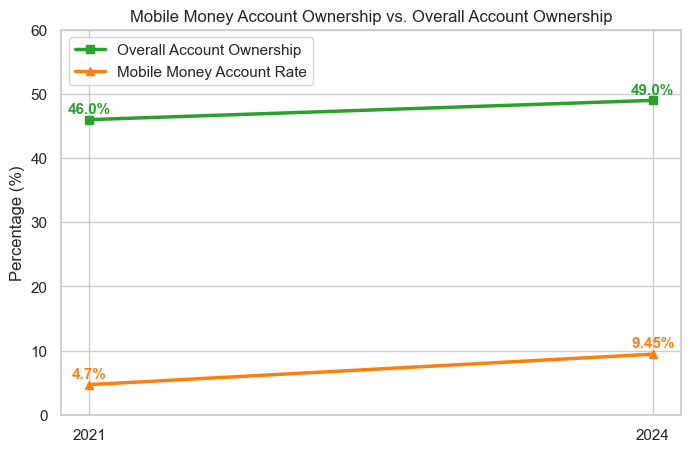

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
years_mm = [2021, 2024]
acc_vals = [46.0, 49.0]
mm_vals = [4.70, 9.45]
ax.plot(years_mm, acc_vals, marker='s', color='#2ca02c', linewidth=2.5, label='Overall Account Ownership')
ax.plot(years_mm, mm_vals, marker='^', color='#ff7f0e', linewidth=2.5, label='Mobile Money Account Rate')
for y, a_val, m_val in zip(years_mm, acc_vals, mm_vals):
    ax.text(y, a_val + 1, f'{a_val}%', ha='center', color='#2ca02c', fontweight='bold')
    ax.text(y, m_val + 1, f'{m_val}%', ha='center', color='#ff7f0e', fontweight='bold')
ax.set_xticks(years_mm)
ax.set_ylim(0, 60)
ax.set_title('Mobile Money Account Ownership vs. Overall Account Ownership')
ax.set_ylabel('Percentage (%)')
ax.legend()
plt.show()

## 5. Infrastructure & Enablers Analysis
We plot connectivity infrastructure enablers: 4G Coverage and Fayda Digital ID enrollments.

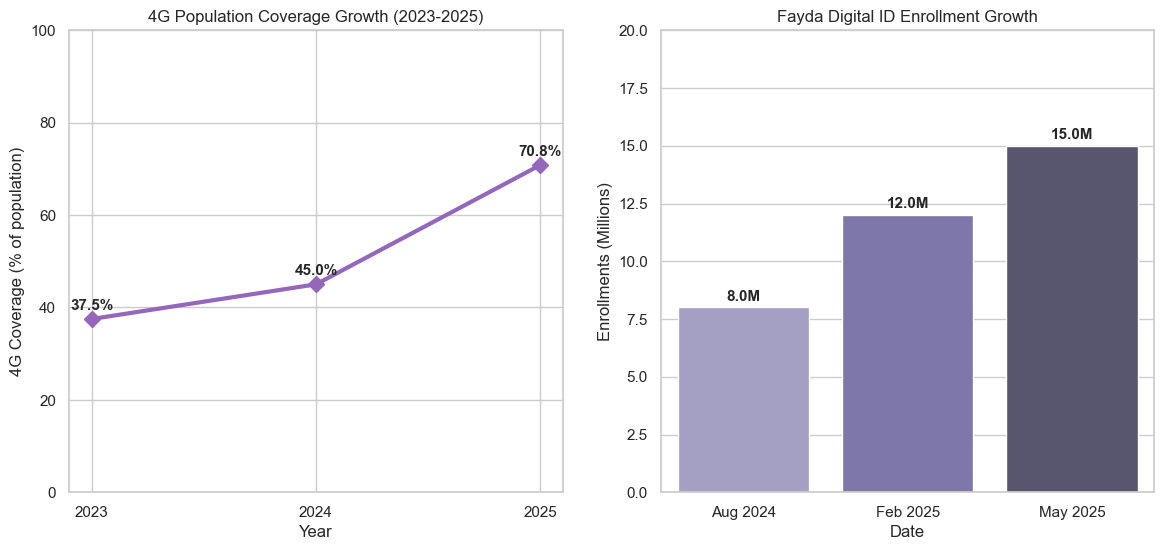

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cov_x = [2023, 2024, 2025]
cov_y = [37.5, 45.0, 70.8]
ax1.plot(cov_x, cov_y, marker='D', color='#9467bd', linewidth=3, markersize=8)
for x_val, y_val in zip(cov_x, cov_y):
    ax1.text(x_val, y_val + 2, f'{y_val}%', ha='center', fontweight='bold')
ax1.set_title('4G Population Coverage Growth (2023-2025)')
ax1.set_xlabel('Year')
ax1.set_ylabel('4G Coverage (% of population)')
ax1.set_ylim(0, 100)
ax1.set_xticks(cov_x)

fayda_dates = ['Aug 2024', 'Feb 2025', 'May 2025']
fayda_regs = [8.0, 12.0, 15.0]
sns.barplot(x=fayda_dates, y=fayda_regs, ax=ax2, palette='Purples_d')
for idx, val in enumerate(fayda_regs):
    ax2.text(idx, val + 0.3, f'{val}M', ha='center', fontweight='bold')
ax2.set_title('Fayda Digital ID Enrollment Growth')
ax2.set_xlabel('Date')
ax2.set_ylabel('Enrollments (Millions)')
ax2.set_ylim(0, 20)
plt.show()

## 6. Event Timeline Overlay
We visualize key milestones in the financial inclusion space between 2021 and 2025.

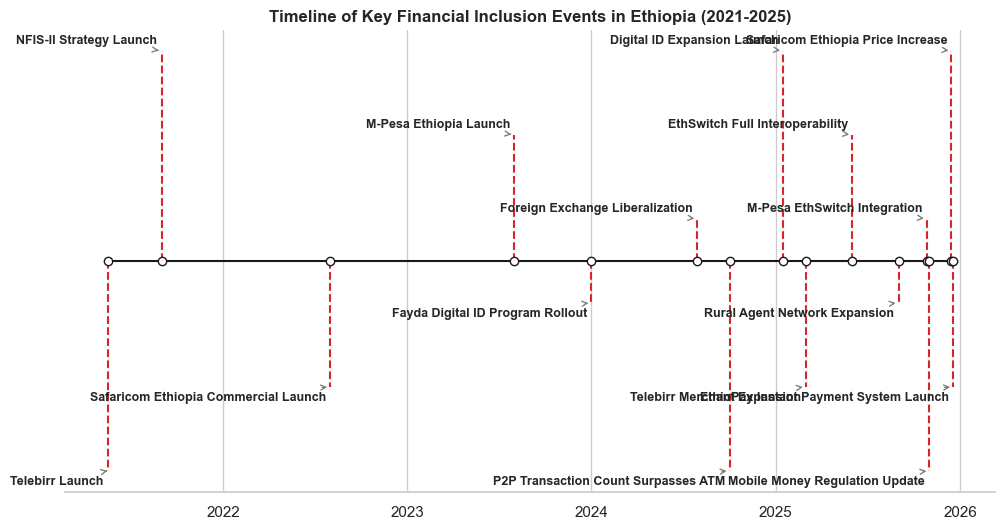

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
events_sorted = events.sort_values(by='observation_date')
dates = pd.to_datetime(events_sorted['observation_date'])
labels = events_sorted['indicator']
levels = np.tile([-5, 5, -3, 3, -1, 1], int(np.ceil(len(labels)/6)))[:len(labels)]
ax.vlines(dates, 0, levels, color='tab:red', linestyles='--')
ax.plot(dates, np.zeros_like(dates), '-o', color='k', markerfacecolor='w')
for d, l, r in zip(dates, levels, labels):
    ax.annotate(r, xy=(d, l), xytext=(-3, np.sign(l)*3),
                textcoords='offset points',
                horizontalalignment='right',
                verticalalignment='bottom' if l > 0 else 'top',
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9, weight='bold', wrap=True)
ax.set_title('Timeline of Key Financial Inclusion Events in Ethiopia (2021-2025)', fontweight='bold')
ax.yaxis.grid(False)
ax.xaxis.grid(True)
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()

## 7. Correlation Analysis
We inspect the relationships between numeric variables in our observations.

In [9]:
obs_numeric = obs.pivot_table(
    index='observation_date', 
    columns='indicator_code', 
    values='value_numeric'
).interpolate(method='time').fillna(method='bfill').fillna(method='ffill')

corr_matrix = obs_numeric.corr()
print('--- Indicator Correlation Matrix ---')
print(corr_matrix[['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT']].round(3))

--- Indicator Correlation Matrix ---
indicator_code              ACC_OWNERSHIP  ACC_MM_ACCOUNT
indicator_code                                           
ACC_4G_COV                          0.624           0.904
ACC_FAYDA                           0.391           0.608
ACC_MM_ACCOUNT                      0.768           1.000
ACC_MOBILE_PEN                        NaN             NaN
ACC_OWNERSHIP                       1.000           0.768
AFF_DATA_INCOME                       NaN             NaN
GEN_GAP_ACC                        -0.768          -1.000
GEN_GAP_MOBILE                        NaN             NaN
GEN_MM_SHARE                          NaN             NaN
INF_4G_COVERAGE                       NaN             NaN
INF_AGENT_DENSITY                     NaN             NaN
INF_ATM_DENSITY                       NaN             NaN
INF_DIGITAL_ID_COVERAGE               NaN             NaN
INF_ELECTRICITY_ACCESS                NaN             NaN
INF_MOBILE_PENETRATION             

## 8. Summary of Key Insights
Based on our exploratory data analysis, here are the key insights:

1. **The Deceleration Paradox (2021-2024 slowdown):** Despite mobile money user registration exploding (Telebirr surpassing 54M users), the Global Findex account ownership rate grew only +3pp (from 46% to 49%). This indicates a substantial registration-to-usage gap. Most users opening telco-backed wallets were likely already banked or remained inactive after registering.
2. **Extremely Low Mobile Money-Only Penetration:** Unlike East African peers (e.g. Kenya, Tanzania), where mobile money-only is the primary inclusion driver, in Ethiopia mobile money-only users make up less than 0.5% of the population. Bank accounts are highly accessible and remain the preferred account type.
3. **Persistent Gender Gap:** The gender gap in account ownership is still high at 18pp (down slightly from 20pp in 2021). Women account for only 14% of mobile money users, driven by a 24% gap in mobile phone ownership.
4. **Shift from Cash to Digital Payment:** For the first time in FY2024/25, interoperable P2P digital transaction volumes (128.3 million) surpassed ATM transaction volumes (119.3 million), marking a crossover ratio of 1.08 and showcasing a clear mindset shift toward digital money use.
5. **Infrastructure and Identity Enablers:** Rapid expansion of 4G population coverage (doubled from 37.5% in 2023 to 70.8% in 2025) and national biometric ID enrollment (Fayda reaching 15M in mid-2025) serve as vital enablers for frictionless onboarding and increased usage.
